In [1]:
# Install required libraries
!pip install xgboost --quiet

# Import everything
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# Load the IBM Telco Churn dataset directly from URL
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Drop customerID (not useful for prediction)
df = df.drop('customerID', axis=1)

# Fix TotalCharges column (has spaces instead of NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Encode target variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Encode all categorical columns
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("✅ Data cleaned and preprocessed!")
print(f"\nChurn distribution:")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].mean()*100:.1f}%")

✅ Data cleaned and preprocessed!

Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 26.5%


In [4]:
# Define features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Data split complete!")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

✅ Data split complete!
Training samples: 5634
Testing samples: 1409


In [5]:
# Define all 3 models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

# Train and evaluate each model
results = {}

for name, model in models.items():
    # Use scaled data for Logistic Regression, raw for tree models
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    # Store results
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }
    print(f"✅ {name} trained!")

print("\n🎯 All models trained successfully!")

✅ Logistic Regression trained!
✅ Random Forest trained!
✅ XGBoost trained!

🎯 All models trained successfully!


In [6]:
# Create results dataframe
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)

print("=" * 60)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 60)
print(results_df.to_string())
print("=" * 60)

MODEL PERFORMANCE COMPARISON
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.7991     0.6426  0.5481    0.5916   0.8403
Random Forest          0.7921     0.6373  0.5027    0.5620   0.8225
XGBoost                0.7786     0.5957  0.5160    0.5530   0.8185


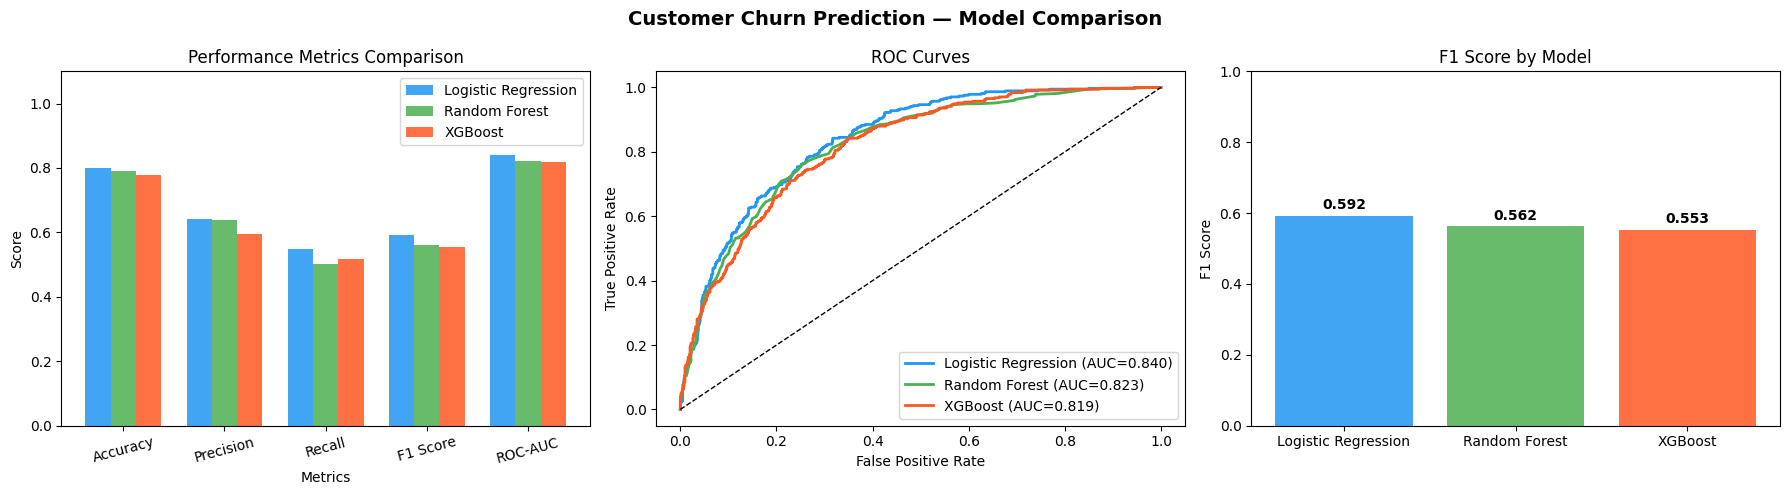

✅ Chart saved as 'churn_model_comparison.png'


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Customer Churn Prediction — Model Comparison',
             fontsize=14, fontweight='bold')

# Plot 1 — Performance Metrics Bar Chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25
colors = ['#2196F3', '#4CAF50', '#FF5722']

for i, (model_name, color) in enumerate(zip(results.keys(), colors)):
    values = [results[model_name][m] for m in metrics]
    axes[0].bar(x + i*width, values, width, label=model_name, color=color, alpha=0.85)

axes[0].set_xlabel('Metrics')
axes[0].set_ylabel('Score')
axes[0].set_title('Performance Metrics Comparison')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics, rotation=15)
axes[0].legend()
axes[0].set_ylim(0, 1.1)

# Plot 2 — ROC Curves
model_list = list(models.items())
for i, (name, model) in enumerate(model_list):
    if name == 'Logistic Regression':
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = results[name]['ROC-AUC']
    axes[1].plot(fpr, tpr, color=colors[i],
                label=f'{name} (AUC={auc:.3f})', linewidth=2)

axes[1].plot([0,1], [0,1], 'k--', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves')
axes[1].legend()

# Plot 3 — F1 Score Comparison
model_names = list(results.keys())
f1_scores = [results[m]['F1 Score'] for m in model_names]
bars = axes[2].bar(model_names, f1_scores, color=colors, alpha=0.85)
axes[2].set_ylabel('F1 Score')
axes[2].set_title('F1 Score by Model')
axes[2].set_ylim(0, 1)
for bar, score in zip(bars, f1_scores):
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('churn_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Chart saved as 'churn_model_comparison.png'")

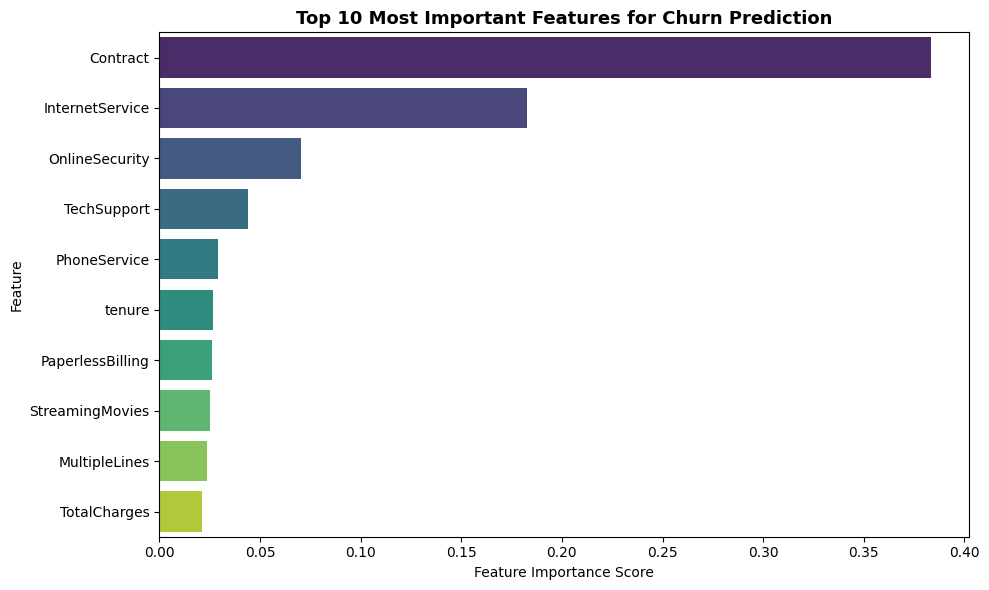


✅ Feature importance chart saved!

Top 5 churn predictors:
        Feature  Importance
       Contract    0.383310
InternetService    0.182803
 OnlineSecurity    0.070600
    TechSupport    0.044101
   PhoneService    0.029047


In [8]:
# Get feature importance from XGBoost
xgb_model = models['XGBoost']
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature',
            palette='viridis')
plt.title('Top 10 Most Important Features for Churn Prediction',
          fontsize=13, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Feature importance chart saved!")
print("\nTop 5 churn predictors:")
print(feature_importance.head().to_string(index=False))